# 06c — Retrieval v2: cleaner evidence and adaptive source selection

**Notebook version: 06c-rag-retrieval-v2**

本 Notebook 修正 06b 暴露的检索问题，不调用 LLM/API，也不需要 API Key。

主要变化：

1. Manifesto 按 PDF 阅读顺序逐页提取，再在页内分块，避免跨页混合；
2. 历史投票的检索文本不再包含 party、observed stance、motion type 和 motion family 等模板词；
3. 查询提高 motion title、policy object 和 legislation name 的权重，并限制冗长 motion text 的长度；
4. Policy domain 只作为小幅加分，不作为硬过滤条件；
5. Bill 不再固定占一个位置，只有直接匹配或达到较高相似度时才进入结果；
6. 允许少于八条证据，避免为了凑数加入明显无关资料；
7. 使用与 06b 完全相同的可复现分层抽样方法，并输出24条议案清单。

本步骤仍是检索审计，不使用 Test 标签，也不生成最终 Test 结果。

## 1. Imports and configuration

In [1]:
# 导入知识库重建、稀疏检索、审计和绘图需要的库。
from pathlib import Path
import ast
import hashlib
import re
import shutil
import subprocess
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 200)

NOTEBOOK_VERSION = '06c-rag-retrieval-v2'
RANDOM_STATE = 42
PARTIES = ['conservative', 'green', 'labour', 'liberal-democrat']
TARGET = 'target_binary_support'

# 以下参数控制与06b一致的审计样本。
TARGET_DIVISIONS = 24
PER_DOMAIN_TARGET = 2

# 以下参数控制文本切分和字段权重。
MANIFESTO_CHUNK_SIZE = 1200
MANIFESTO_CHUNK_OVERLAP = 150
HISTORICAL_CHUNK_SIZE = 1400
HISTORICAL_CHUNK_OVERLAP = 160
QUERY_MOTION_MAX_CHARS = 1800
TITLE_REPEAT = 4
POLICY_OBJECT_REPEAT = 5
LEGISLATION_REPEAT = 3
DOMAIN_REPEAT = 2

# 以下参数控制自适应证据选择。
TOP_K = 8
POLICY_QUOTA = 2
HISTORICAL_BASE_QUOTA = 4
POLICY_MIN_SCORE = 0.015
HISTORICAL_MIN_SCORE = 0.020
FILL_MIN_SCORE = 0.025
BILL_MIN_SCORE = 0.080
DOMAIN_MATCH_BOOST = 0.035
TITLE_OVERLAP_WEIGHT = 0.060
MAX_CHUNKS_PER_DOCUMENT = 2

ROOT = Path.cwd()
MODEL_DIR = ROOT / 'processed' / 'model_v2'
RAG_V1_DIR = ROOT / 'processed' / 'rag_v1'
AUDIT_V1_DIR = ROOT / 'processed' / 'rag_audit_v1'
RAG_V2_DIR = ROOT / 'processed' / 'rag_v2'
AUDIT_V2_DIR = ROOT / 'processed' / 'rag_audit_v2'
RAG_V2_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_V2_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = MODEL_DIR / 'model_train_v2.csv'
VALIDATION_PATH = MODEL_DIR / 'model_validation_v2.csv'
TEST_PATH = MODEL_DIR / 'model_test_v2.csv'
SOURCE_REGISTRY_PATH = RAG_V1_DIR / 'official_policy_source_registry.csv'
V1_AUDIT_EVIDENCE_PATH = AUDIT_V1_DIR / 'retrieval_audit_evidence.csv'
BILL_INFO_PATH = ROOT / 'data' / 'raw' / 'bill_info.csv'

print('Notebook version:', NOTEBOOK_VERSION)
print('API calls enabled: False')
print('LLM calls enabled: False')
print('RAG v2 output:', RAG_V2_DIR)
print('Audit output:', AUDIT_V2_DIR)

Notebook version: 06c-rag-retrieval-v2
API calls enabled: False
LLM calls enabled: False
RAG v2 output: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/rag_v2
Audit output: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/rag_audit_v2


## 2. Load source data and enforce the Test boundary

Train 和 Validation 可以作为已经发生的历史证据，但每次检索仍要求 `source_date < query_date`。Test 只读取 `division_key` 做隔离检查，Test 标签不会进入知识库。

In [2]:
# 检查必要输入并读取数据。
required_paths = [
    TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH,
    SOURCE_REGISTRY_PATH,
    BILL_INFO_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('缺少必要文件：\n' + '\n'.join(missing_paths))

train = pd.read_csv(TRAIN_PATH, parse_dates=['motion_date'])
validation = pd.read_csv(VALIDATION_PATH, parse_dates=['motion_date'])
test_keys = pd.read_csv(TEST_PATH, usecols=['division_key'])
source_registry = pd.read_csv(
    SOURCE_REGISTRY_PATH,
    parse_dates=['published_at'],
)
bill_info = pd.read_csv(BILL_INFO_PATH, low_memory=False)

development_votes = pd.concat([
    train.assign(source_split='train'),
    validation.assign(source_split='validation'),
], ignore_index=True)
development_votes = development_votes[
    development_votes[TARGET].notna()
].copy()

assert development_votes['row_id'].is_unique
assert not set(development_votes['division_key']) & set(test_keys['division_key'])

display(pd.DataFrame({
    'dataset': ['train', 'validation', 'development', 'test_keys'],
    'rows': [len(train), len(validation), len(development_votes), len(test_keys)],
    'divisions': [
        train['division_key'].nunique(),
        validation['division_key'].nunique(),
        development_votes['division_key'].nunique(),
        test_keys['division_key'].nunique(),
    ],
}))

,dataset,rows,divisions
0,train,2822,770
1,validation,570,169
2,development,3392,939
3,test_keys,1289,354


## 3. Reproduce the 06b audit sample

这24条议案不是简单随机抽取。

抽样顺序是：

1. 只保留 2024-07-05 之后的 Validation division；
2. 按实际存在的 `policy_domain_primary` 分层；
3. 每个领域使用固定随机种子42抽取最多两条；
4. 如果不足24条，再从尚未入选的议案中使用固定随机种子43补足；
5. 最后按日期和 division key 排序。

固定随机种子的意义是每次运行都会得到相同的24条。四个政党共用这24条，因此 Green 与其他政党的比较是配对比较。

In [3]:
# 复现06b的可重复分层抽样，并保存完整抽样清单。
allowed_query_columns = [
    'division_key', 'motion_date', 'motion_title_clean', 'motion_text_clean',
    'motion_type', 'motion_family', 'policy_domain_primary',
    'final_policy_object', 'legislation_name_clean',
]
post_election_divisions = (
    validation.loc[
        validation['motion_date'].ge('2024-07-05'),
        allowed_query_columns,
    ]
    .drop_duplicates('division_key')
    .sort_values(['motion_date', 'division_key'])
    .reset_index(drop=True)
)

selected_parts = []
for domain, group in post_election_divisions.groupby(
    'policy_domain_primary', sort=True
):
    selected = group.sample(
        n=min(PER_DOMAIN_TARGET, len(group)),
        random_state=RANDOM_STATE,
    ).copy()
    selected['sampling_stage'] = 'domain_stratified'
    selected_parts.append(selected)

audit_divisions = (
    pd.concat(selected_parts, ignore_index=True)
    .drop_duplicates('division_key')
)

if len(audit_divisions) < TARGET_DIVISIONS:
    remaining = post_election_divisions[
        ~post_election_divisions['division_key'].isin(
            audit_divisions['division_key']
        )
    ]
    fill_count = min(
        TARGET_DIVISIONS - len(audit_divisions),
        len(remaining),
    )
    if fill_count:
        fill = remaining.sample(
            n=fill_count,
            random_state=RANDOM_STATE + 1,
        ).copy()
        fill['sampling_stage'] = 'random_fill'
        audit_divisions = pd.concat([
            audit_divisions,
            fill,
        ], ignore_index=True)

audit_divisions = (
    audit_divisions
    .sort_values(['motion_date', 'division_key'])
    .head(TARGET_DIVISIONS)
    .reset_index(drop=True)
)
audit_divisions['audit_order'] = np.arange(1, len(audit_divisions) + 1)

assert audit_divisions['division_key'].is_unique
audit_divisions.to_csv(
    AUDIT_V2_DIR / 'audit_divisions_v2.csv',
    index=False,
)

display(pd.DataFrame({
    'value': [
        len(audit_divisions),
        len(audit_divisions) * len(PARTIES),
        audit_divisions['policy_domain_primary'].nunique(),
        audit_divisions['motion_family'].nunique(),
        audit_divisions['motion_date'].min(),
        audit_divisions['motion_date'].max(),
    ]
}, index=[
    'audit_divisions',
    'party_queries',
    'policy_domains',
    'motion_families',
    'earliest_date',
    'latest_date',
]))
display(audit_divisions[[
    'audit_order', 'sampling_stage', 'division_key', 'motion_date',
    'motion_title_clean', 'policy_domain_primary', 'motion_family',
]])

,value
audit_divisions,24
party_queries,96
policy_domains,12
motion_families,4
earliest_date,2024-07-23 00:00:00
latest_date,2024-12-17 00:00:00


,audit_order,sampling_stage,division_key,motion_date,motion_title_clean,policy_domain_primary,motion_family
0,1,domain_stratified,pw-2024-07-23-2-commons,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,other_motion
1,2,domain_stratified,pw-2024-07-23-3-commons,2024-07-23,Immigration and Home Affairs,welfare_pensions_poverty,other_motion
2,3,domain_stratified,pw-2024-07-23-4-commons,2024-07-23,Immigration and Home Affairs,education_skills_children,other_motion
3,4,domain_stratified,pw-2024-07-25-5-commons,2024-07-25,Approve: Criminal Justice Act 2003 (Requisite and Minimum Custodial Periods) Order 2024,justice_crime_policing,delegated_legislation
4,5,domain_stratified,pw-2024-07-29-6-commons,2024-07-29,Second Reading: Passenger Railway Services (Public Ownership) Bill,transport_infrastructure,bill_stage
5,6,domain_stratified,pw-2024-09-03-7-commons,2024-09-03,Clause 2 - Future provision of services,transport_infrastructure,amendment_or_clause
6,7,random_fill,pw-2024-09-05-13-commons,2024-09-05,Second Reading: Great British Energy Bill,environment_energy_water,bill_stage
7,8,domain_stratified,pw-2024-09-10-14-commons,2024-09-10,Social Security,welfare_pensions_poverty,other_motion
8,9,domain_stratified,pw-2024-10-08-16-commons,2024-10-08,VAT: Independent Schools,education_skills_children,other_motion
9,10,domain_stratified,pw-2024-10-08-17-commons,2024-10-08,Farming and Food Security,agriculture_food_rural,other_motion


## 4. Text helpers

`evidence_text` 是之后交给 Agent 阅读的完整证据；`retrieval_text` 只用于计算相似度。把两者分开可以保留立场和来源信息，同时避免模板字段干扰检索排名。

In [4]:
# 定义文本清理、分块、标识符和词语重叠函数。
def safe_text(value):
    # 把缺失值安全转换为空字符串。
    if value is None or pd.isna(value):
        return ''
    return str(value).strip()


def clean_text(value):
    # 保留有效换行，同时压缩重复空格和空行。
    value = safe_text(value).replace('\x00', ' ')
    lines = [re.sub(r'\s+', ' ', line).strip() for line in value.splitlines()]
    lines = [line for line in lines if line]
    return '\n'.join(lines)


def split_text(text, chunk_size, overlap):
    # 优先在接近上限的段落、句号或空格处切分。
    text = clean_text(text)
    if not text:
        return []
    if len(text) <= chunk_size:
        return [(0, len(text), text)]

    parts = []
    start = 0
    while start < len(text):
        target_end = min(start + chunk_size, len(text))
        end = target_end
        if target_end < len(text):
            candidates = [
                text.rfind('\n', start + chunk_size // 2, target_end),
                text.rfind('. ', start + chunk_size // 2, target_end),
                text.rfind(' ', start + chunk_size // 2, target_end),
            ]
            valid = [position for position in candidates if position > start]
            if valid:
                end = max(valid) + 1

        chunk_text = text[start:end].strip()
        if chunk_text:
            parts.append((start, end, chunk_text))
        if end >= len(text):
            break
        next_start = max(0, end - overlap)
        start = end if next_start <= start else next_start
    return parts


def make_chunk_id(document_id, chunk_index, retrieval_text):
    # 使用稳定哈希生成可追踪且可重复的chunk ID。
    digest = hashlib.sha256(
        f'{document_id}|{chunk_index}|{retrieval_text}'.encode('utf-8')
    ).hexdigest()[:20]
    return f'chunk_v2_{digest}'


def word_set(value):
    # 只保留至少两个字符的英文与数字词，用于标题重叠诊断。
    return set(re.findall(r'[a-z0-9][a-z0-9\-]{1,}', safe_text(value).lower()))


def jaccard_overlap(left, right):
    # 计算两个词集合的Jaccard重叠率。
    left_words = word_set(left)
    right_words = word_set(right)
    union = left_words | right_words
    if not union:
        return 0.0
    return len(left_words & right_words) / len(union)

## 5. Re-extract and re-chunk official manifestos

05 使用 `pdftotext -layout`，多栏 PDF 可能把左右栏内容拼到同一行。06c 改用默认阅读顺序，并先按 PDF 页分开，再在每页内部切分。常见页眉、口号和纯页码会被移除。

这种方法比按整份 PDF 连续切分更稳，但仍不是完美的语义分段。人工审核如果仍发现栏目顺序问题，下一步再升级为坐标级栏位识别。

In [5]:
# 逐页提取官方manifesto并创建检索块。
PDF_NOISE_LINES = {
    'real hope.',
    'real change.',
    're al hope.',
    're al change.',
}


def clean_manifesto_page(page_text):
    # 删除常见页眉、口号、纯页码和印刷说明。
    cleaned_lines = []
    for raw_line in safe_text(page_text).splitlines():
        line = re.sub(r'\s+', ' ', raw_line).strip()
        lowered = line.lower()
        if not line:
            continue
        if lowered in PDF_NOISE_LINES:
            continue
        if re.fullmatch(r'\d{1,3}', line):
            continue
        if lowered.startswith('promoted by '):
            continue
        if lowered.startswith('printed by '):
            continue
        cleaned_lines.append(line)
    return '\n'.join(cleaned_lines)


def extract_pdf_pages(path):
    # 使用pdftotext默认阅读顺序，并通过分页符保留页面边界。
    executable = shutil.which('pdftotext')
    if not executable:
        raise RuntimeError('未找到pdftotext，请在当前环境安装Poppler。')
    result = subprocess.run(
        [executable, str(path), '-'],
        check=True,
        capture_output=True,
        text=True,
    )
    return [clean_manifesto_page(page) for page in result.stdout.split('\f')]


manifesto_rows = []
manifesto_extraction_audit = []

for _, source in source_registry.iterrows():
    local_path = Path(source['local_path'])
    if not local_path.exists():
        raise FileNotFoundError(f'未找到官方政策文件：{local_path}')

    pages = extract_pdf_pages(local_path)
    nonempty_pages = [page for page in pages if page]
    document_id = safe_text(source['document_id'])
    document_chunk_count = 0

    for page_number, page_text in enumerate(pages, start=1):
        if not page_text:
            continue
        for local_index, (start, end, body) in enumerate(split_text(
            page_text,
            chunk_size=MANIFESTO_CHUNK_SIZE,
            overlap=MANIFESTO_CHUNK_OVERLAP,
        )):
            chunk_index = document_chunk_count
            retrieval_text = clean_text(
                f"{source['title']}\n{body}"
            )
            chunk_id = make_chunk_id(
                document_id,
                chunk_index,
                retrieval_text,
            )
            manifesto_rows.append({
                'chunk_id': chunk_id,
                'document_id': document_id,
                'chunk_index': chunk_index,
                'party': source['party'],
                'source_type': 'manifesto',
                'title': source['title'],
                'source_url': source['url'],
                'source_date': source['published_at'],
                'division_key': pd.NA,
                'motion_type': pd.NA,
                'motion_family': pd.NA,
                'policy_domain': pd.NA,
                'stance_label': pd.NA,
                'page_number': page_number,
                'start_char': start,
                'end_char': end,
                'retrieval_text': retrieval_text,
                'evidence_text': body,
            })
            document_chunk_count += 1

    manifesto_extraction_audit.append({
        'document_id': document_id,
        'party': source['party'],
        'pages_detected': len(pages),
        'nonempty_pages': len(nonempty_pages),
        'chunks': document_chunk_count,
        'characters': sum(len(page) for page in nonempty_pages),
    })

manifesto_chunks = pd.DataFrame(manifesto_rows)
manifesto_extraction_audit = pd.DataFrame(manifesto_extraction_audit)
display(manifesto_extraction_audit)

,document_id,party,pages_detected,nonempty_pages,chunks,characters
0,manifesto_2024_labour,labour,137,131,215,168302
1,manifesto_2024_conservative,conservative,81,72,200,167182
2,manifesto_2024_liberal_democrat,liberal-democrat,136,134,192,146176
3,manifesto_2024_green,green,29,27,130,123454


## 6. Build historical-vote retrieval chunks

每条历史证据仍保留 observed stance，供最终 Agent 判断，但 stance、party、motion type、motion family 和 policy domain 不进入 `retrieval_text`。

政党通过元数据过滤，领域通过后续小幅加分，因此不需要把这些模板标签写进检索文本。

In [6]:
# 从Train和Validation建立历史投票检索块。
historical_rows = []

for _, row in development_votes.iterrows():
    title = clean_text(row.get('motion_title_clean'))
    motion_text = clean_text(row.get('motion_text_clean'))
    legislation = clean_text(row.get('legislation_name_clean'))
    stance = 'support' if int(row[TARGET]) == 1 else 'oppose'
    document_id = f"historical_vote_{row['row_id']}"

    body_parts = split_text(
        motion_text or title,
        chunk_size=HISTORICAL_CHUNK_SIZE,
        overlap=HISTORICAL_CHUNK_OVERLAP,
    )
    if not body_parts:
        continue

    for chunk_index, (start, end, body) in enumerate(body_parts):
        retrieval_text = clean_text('\n'.join([
            title,
            title,
            body,
            legislation,
        ]))
        evidence_text = clean_text(
            f'Historical parliamentary vote.\n'
            f"Party: {row['party']}.\n"
            f'Observed stance: {stance}.\n'
            f'Motion title: {title}.\n'
            f'Motion text: {body}.\n'
            f'Legislation: {legislation}.'
        )
        historical_rows.append({
            'chunk_id': make_chunk_id(
                document_id,
                chunk_index,
                retrieval_text,
            ),
            'document_id': document_id,
            'chunk_index': chunk_index,
            'party': row['party'],
            'source_type': 'historical_vote',
            'title': title,
            'source_url': pd.NA,
            'source_date': row['motion_date'],
            'division_key': row['division_key'],
            'motion_type': row.get('motion_type', pd.NA),
            'motion_family': row.get('motion_family', pd.NA),
            'policy_domain': row.get('policy_domain_primary', pd.NA),
            'stance_label': stance,
            'page_number': pd.NA,
            'start_char': start,
            'end_char': end,
            'retrieval_text': retrieval_text,
            'evidence_text': evidence_text,
        })

historical_chunks = pd.DataFrame(historical_rows)
display(pd.DataFrame({
    'historical_documents': [historical_chunks['document_id'].nunique()],
    'historical_chunks': [len(historical_chunks)],
    'historical_divisions': [historical_chunks['division_key'].nunique()],
    'earliest_date': [historical_chunks['source_date'].min()],
    'latest_date': [historical_chunks['source_date'].max()],
}))

,historical_documents,historical_chunks,historical_divisions,earliest_date,latest_date
0,3392,3751,939,2016-01-06,2024-12-17


## 7. Build concise Bill reference chunks

Bill 检索文本只保留 title、long title 和 summary。原来的完整 `currentStage` 字典包含内部 ID 等无关文字，06c 只保留阶段名称用于展示。

In [7]:
# 创建简洁的Bill reference检索块。
def parse_stage_description(value):
    # 安全解析字符串形式的字典，只返回阶段说明。
    if value is None or pd.isna(value):
        return ''
    if isinstance(value, dict):
        return safe_text(value.get('description'))
    try:
        parsed = ast.literal_eval(str(value))
    except (ValueError, SyntaxError):
        return ''
    if isinstance(parsed, dict):
        return safe_text(parsed.get('description'))
    return ''


bill_rows = []
for _, row in bill_info.iterrows():
    bill_id = safe_text(row.get('billId'))
    title = clean_text(row.get('shortTitle')) or clean_text(row.get('longTitle'))
    long_title = clean_text(row.get('longTitle'))
    summary = clean_text(row.get('summary'))
    stage = parse_stage_description(row.get('currentStage'))
    source_date = pd.to_datetime(row.get('lastUpdate'), errors='coerce')
    document_id = f'bill_{bill_id or len(bill_rows)}'
    retrieval_text = clean_text('\n'.join([title, title, long_title, summary]))
    if not retrieval_text:
        continue

    for chunk_index, (start, end, body) in enumerate(split_text(
        retrieval_text,
        chunk_size=HISTORICAL_CHUNK_SIZE,
        overlap=HISTORICAL_CHUNK_OVERLAP,
    )):
        evidence_text = clean_text(
            f'Bill reference.\n'
            f'Bill title: {title}.\n'
            f'Long title: {long_title}.\n'
            f'Summary: {summary}.\n'
            f'Current stage: {stage}.'
        )
        bill_rows.append({
            'chunk_id': make_chunk_id(document_id, chunk_index, body),
            'document_id': document_id,
            'chunk_index': chunk_index,
            'party': 'all',
            'source_type': 'bill_reference',
            'title': title,
            'source_url': (
                f'https://bills.parliament.uk/bills/{bill_id}'
                if bill_id else pd.NA
            ),
            'source_date': source_date,
            'division_key': pd.NA,
            'motion_type': pd.NA,
            'motion_family': pd.NA,
            'policy_domain': pd.NA,
            'stance_label': pd.NA,
            'page_number': pd.NA,
            'start_char': start,
            'end_char': end,
            'retrieval_text': body,
            'evidence_text': evidence_text,
        })

bill_chunks = pd.DataFrame(bill_rows)
print('Bill documents:', bill_chunks['document_id'].nunique())
print('Bill chunks:', len(bill_chunks))

Bill documents: 129
Bill chunks: 130


## 8. Combine chunks and build the sparse v2 index

TF-IDF 只学习 `retrieval_text`。`evidence_text`、stance 和其他元数据不会影响词语权重。

In [8]:
# 合并三类证据、去重并建立TF-IDF索引。
chunks_v2 = pd.concat([
    manifesto_chunks,
    historical_chunks,
    bill_chunks,
], ignore_index=True)
chunks_v2['source_date'] = pd.to_datetime(
    chunks_v2['source_date'], errors='coerce'
)
chunks_v2['retrieval_text'] = chunks_v2['retrieval_text'].fillna('').astype(str)
chunks_v2['evidence_text'] = chunks_v2['evidence_text'].fillna('').astype(str)
chunks_v2['retrieval_char_count'] = chunks_v2['retrieval_text'].str.len()
chunks_v2['evidence_char_count'] = chunks_v2['evidence_text'].str.len()

# 只删除同政党、同来源内完全相同的检索文本。
chunks_v2['retrieval_hash'] = chunks_v2['retrieval_text'].map(
    lambda value: hashlib.sha256(
        re.sub(r'\s+', ' ', value).strip().lower().encode('utf-8')
    ).hexdigest()
)
before_deduplication = len(chunks_v2)
chunks_v2 = chunks_v2.drop_duplicates(
    subset=['party', 'source_type', 'retrieval_hash']
).reset_index(drop=True)

vectorizer_v2 = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.98,
    sublinear_tf=True,
    norm='l2',
    max_features=80000,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z\-]{1,}\b',
)
sparse_matrix_v2 = vectorizer_v2.fit_transform(
    chunks_v2['retrieval_text']
)

assert chunks_v2['chunk_id'].is_unique
assert chunks_v2['retrieval_text'].str.len().gt(0).all()
assert sparse_matrix_v2.shape[0] == len(chunks_v2)

chunks_v2.to_csv(RAG_V2_DIR / 'rag_chunks_v2.csv', index=False)
chunks_v2.to_json(
    RAG_V2_DIR / 'rag_chunks_v2.jsonl',
    orient='records',
    lines=True,
    force_ascii=False,
    date_format='iso',
)
save_npz(RAG_V2_DIR / 'sparse_tfidf_matrix_v2.npz', sparse_matrix_v2)
joblib.dump(
    vectorizer_v2,
    RAG_V2_DIR / 'sparse_tfidf_vectorizer_v2.joblib',
)
manifesto_extraction_audit.to_csv(
    RAG_V2_DIR / 'manifesto_extraction_audit_v2.csv',
    index=False,
)

source_summary = (
    chunks_v2
    .groupby('source_type')
    .agg(
        chunks=('chunk_id', 'size'),
        documents=('document_id', 'nunique'),
        mean_retrieval_chars=('retrieval_char_count', 'mean'),
        min_date=('source_date', 'min'),
        max_date=('source_date', 'max'),
    )
)
print('Chunks before deduplication:', before_deduplication)
print('Chunks after deduplication:', len(chunks_v2))
print('Sparse index shape:', sparse_matrix_v2.shape)
display(source_summary.round(1))

Chunks before deduplication: 4618
Chunks after deduplication: 4504
Sparse index shape: (4504, 74188)


,chunks,documents,mean_retrieval_chars,min_date,max_date
source_type,,,,,
bill_reference,130,129,350.6,2008-10-30 18:56:00,2026-03-06 18:59:29.884718700
historical_vote,3642,3283,481.8,2016-01-06 00:00:00,2024-12-17 00:00:00.000000000
manifesto,732,4,946.6,2024-06-10 00:00:00,2024-06-13 00:00:00.000000000


## 9. Weighted query and adaptive retrieval

为什么需要限制长正文：TF-IDF 会把整个查询归一化。如果查询里有很长的法律正文，权重会分散到大量程序性词语上，标题中的核心主题占比就会下降。

06c 通过以下方式修正：

- motion title 重复4次；
- policy object 重复5次；
- legislation name 重复3次；
- policy domain 重复2次；
- motion text 最多保留1,800字符；
- party、party role 和 motion family 不写入查询文本，而是作为过滤或审计元数据。

这里的“重复”只是在构造 TF-IDF 查询向量时提高字段权重，不会修改原始数据。

In [9]:
# 构造加权查询、计算候选分数并执行自适应来源选择。
def repeat_field(value, times):
    # 通过重复字段提高该字段在稀疏查询向量中的权重。
    value = clean_text(value)
    if not value:
        return ''
    return '\n'.join([value] * times)


def build_weighted_query(row):
    # 只使用预测前可获得的文本与结构字段。
    title = clean_text(row.get('motion_title_clean'))
    policy_object = clean_text(row.get('final_policy_object'))
    legislation = clean_text(row.get('legislation_name_clean'))
    domain = clean_text(row.get('policy_domain_primary')).replace('_', ' ')
    motion_text = clean_text(row.get('motion_text_clean'))[
        :QUERY_MOTION_MAX_CHARS
    ]
    return clean_text('\n'.join([
        repeat_field(title, TITLE_REPEAT),
        repeat_field(policy_object, POLICY_OBJECT_REPEAT),
        repeat_field(legislation, LEGISLATION_REPEAT),
        repeat_field(domain, DOMAIN_REPEAT),
        motion_text,
    ]))


def candidate_mask(party, query_date, exclude_division_key):
    # 只允许目标政党、严格早于查询日期且不属于当前division的证据。
    query_date = pd.Timestamp(query_date)
    party_ok = chunks_v2['party'].isin([party, 'all']).to_numpy()
    date_ok = (
        chunks_v2['source_date'].lt(query_date).fillna(False).to_numpy()
    )
    division_ok = (
        chunks_v2['division_key']
        .ne(exclude_division_key)
        .fillna(True)
        .to_numpy()
    )
    return party_ok & date_ok & division_ok


def bill_direct_match(query_row, evidence_title):
    # legislation名称或motion标题与Bill标题直接包含时视为直接匹配。
    bill_title = clean_text(evidence_title).lower()
    if not bill_title:
        return False
    candidates = [
        clean_text(query_row.get('legislation_name_clean')).lower(),
        clean_text(query_row.get('motion_title_clean')).lower(),
    ]
    for value in candidates:
        if not value:
            continue
        if bill_title in value or value in bill_title:
            return True
    return False


def score_candidates(query_row, party):
    # 计算基础TF-IDF分数、领域加分和标题重叠加分。
    mask = candidate_mask(
        party=party,
        query_date=query_row['motion_date'],
        exclude_division_key=query_row['division_key'],
    )
    indices = np.flatnonzero(mask)
    if not len(indices):
        return pd.DataFrame()

    query_text = build_weighted_query(query_row)
    query_vector = vectorizer_v2.transform([query_text])
    base_scores = (
        sparse_matrix_v2[indices] @ query_vector.T
    ).toarray().ravel()

    candidates = chunks_v2.iloc[indices].copy()
    candidates['chunk_index_global'] = indices
    candidates['base_score'] = base_scores
    candidates['title_overlap'] = candidates['title'].map(
        lambda value: jaccard_overlap(
            query_row.get('motion_title_clean'), value
        )
    )
    candidates['same_domain'] = (
        candidates['policy_domain'].fillna('').astype(str)
        .eq(safe_text(query_row.get('policy_domain_primary')))
    )
    candidates['domain_boost'] = np.where(
        candidates['source_type'].eq('historical_vote')
        & candidates['same_domain'],
        DOMAIN_MATCH_BOOST,
        0.0,
    )
    candidates['title_boost'] = (
        candidates['title_overlap'] * TITLE_OVERLAP_WEIGHT
    )
    candidates['adjusted_score'] = (
        candidates['base_score']
        + candidates['domain_boost']
        + candidates['title_boost']
    )
    candidates['bill_direct_match'] = candidates.apply(
        lambda evidence: (
            bill_direct_match(query_row, evidence['title'])
            if evidence['source_type'] == 'bill_reference'
            else False
        ),
        axis=1,
    )
    return candidates.sort_values(
        ['adjusted_score', 'base_score'],
        ascending=False,
    )


def add_candidate(candidate, selected, document_counts, channel):
    # 限制每份原始文档最多贡献两个chunk，并禁止重复chunk。
    chunk_id = candidate['chunk_id']
    if any(item['chunk_id'] == chunk_id for item in selected):
        return False
    document_id = candidate['document_id']
    if document_counts.get(document_id, 0) >= MAX_CHUNKS_PER_DOCUMENT:
        return False
    item = candidate.to_dict()
    item['evidence_channel'] = channel
    selected.append(item)
    document_counts[document_id] = document_counts.get(document_id, 0) + 1
    return True


def select_adaptive(candidates):
    # 先保证政策和历史证据，再按阈值有条件加入Bill和补充证据。
    selected = []
    document_counts = {}

    policy_candidates = candidates[
        candidates['source_type'].eq('manifesto')
        & candidates['base_score'].ge(POLICY_MIN_SCORE)
    ]
    for _, candidate in policy_candidates.iterrows():
        add_candidate(candidate, selected, document_counts, 'policy')
        if sum(item['evidence_channel'] == 'policy' for item in selected) >= POLICY_QUOTA:
            break

    historical_candidates = candidates[
        candidates['source_type'].eq('historical_vote')
        & candidates['adjusted_score'].ge(HISTORICAL_MIN_SCORE)
    ]
    for _, candidate in historical_candidates.iterrows():
        add_candidate(candidate, selected, document_counts, 'historical')
        if sum(item['evidence_channel'] == 'historical' for item in selected) >= HISTORICAL_BASE_QUOTA:
            break

    bill_candidates = candidates[
        candidates['source_type'].eq('bill_reference')
        & (
            candidates['bill_direct_match']
            | candidates['base_score'].ge(BILL_MIN_SCORE)
        )
    ]
    for _, candidate in bill_candidates.head(1).iterrows():
        add_candidate(candidate, selected, document_counts, 'bill')

    eligible_fill = candidates[
        ~candidates['source_type'].eq('bill_reference')
        & candidates['adjusted_score'].ge(FILL_MIN_SCORE)
    ]
    for _, candidate in eligible_fill.iterrows():
        if len(selected) >= TOP_K:
            break
        channel = (
            'policy'
            if candidate['source_type'] == 'manifesto'
            else 'historical'
        )
        add_candidate(candidate, selected, document_counts, channel)

    return selected[:TOP_K]

## 10. Run retrieval v2 on the paired audit sample

In [10]:
# 对24个division和四个政党运行自适应检索。
retrieval_rows = []
query_metric_rows = []

for _, query_row in audit_divisions.iterrows():
    for party in PARTIES:
        candidates = score_candidates(query_row, party)
        selected = select_adaptive(candidates)
        query_id = f"{query_row['division_key']}__{party}__adaptive_v2"

        for rank, evidence in enumerate(selected, start=1):
            retrieval_rows.append({
                'query_id': query_id,
                'query_division_key': query_row['division_key'],
                'query_party': party,
                'query_date': query_row['motion_date'],
                'query_title': query_row['motion_title_clean'],
                'query_motion_text': query_row['motion_text_clean'],
                'query_motion_type': query_row['motion_type'],
                'query_motion_family': query_row['motion_family'],
                'query_policy_domain': query_row['policy_domain_primary'],
                'query_policy_object': query_row.get('final_policy_object'),
                'query_legislation': query_row.get('legislation_name_clean'),
                'rank': rank,
                'evidence_channel': evidence['evidence_channel'],
                'base_score': evidence['base_score'],
                'adjusted_score': evidence['adjusted_score'],
                'domain_boost': evidence['domain_boost'],
                'title_overlap': evidence['title_overlap'],
                'bill_direct_match': evidence['bill_direct_match'],
                'evidence_chunk_id': evidence['chunk_id'],
                'evidence_document_id': evidence['document_id'],
                'evidence_party': evidence['party'],
                'source_type': evidence['source_type'],
                'source_date': evidence['source_date'],
                'source_url': evidence['source_url'],
                'evidence_division_key': evidence['division_key'],
                'evidence_motion_family': evidence['motion_family'],
                'evidence_policy_domain': evidence['policy_domain'],
                'stance_label': evidence['stance_label'],
                'evidence_title': evidence['title'],
                'evidence_text': evidence['evidence_text'],
            })

        query_metric_rows.append({
            'query_id': query_id,
            'query_division_key': query_row['division_key'],
            'query_party': party,
            'query_date': query_row['motion_date'],
            'query_title': query_row['motion_title_clean'],
            'query_policy_domain': query_row['policy_domain_primary'],
            'query_motion_family': query_row['motion_family'],
            'results': len(selected),
            'mean_base_score': np.mean([
                item['base_score'] for item in selected
            ]) if selected else np.nan,
            'mean_adjusted_score': np.mean([
                item['adjusted_score'] for item in selected
            ]) if selected else np.nan,
            'manifesto_results': sum(
                item['source_type'] == 'manifesto' for item in selected
            ),
            'historical_results': sum(
                item['source_type'] == 'historical_vote' for item in selected
            ),
            'bill_results': sum(
                item['source_type'] == 'bill_reference' for item in selected
            ),
        })

retrieval_v2 = pd.DataFrame(retrieval_rows)
query_metrics_v2 = pd.DataFrame(query_metric_rows)
retrieval_v2['query_date'] = pd.to_datetime(retrieval_v2['query_date'])
retrieval_v2['source_date'] = pd.to_datetime(retrieval_v2['source_date'])

print('Party queries:', len(query_metrics_v2))
print('Retrieved evidence rows:', len(retrieval_v2))
display(query_metrics_v2['results'].describe().to_frame('results'))
display(pd.crosstab(
    retrieval_v2['query_party'],
    retrieval_v2['source_type'],
))

Party queries: 96
Retrieved evidence rows: 768


,results
count,96.0
mean,8.0
std,0.0
min,8.0
25%,8.0
50%,8.0
75%,8.0
max,8.0


source_type,bill_reference,historical_vote,manifesto
query_party,,,
conservative,7,137,48
green,7,137,48
labour,7,137,48
liberal-democrat,7,137,48


## 11. Structural and relevance-proxy audit

以下检查可以发现日期泄漏、重复和明显检索偏差，但仍不能取代人工政治语义判断。

In [11]:
# 检查时间、division、重复、文档集中度和证据数量。
retrieval_v2['future_or_same_date'] = (
    retrieval_v2['source_date'] >= retrieval_v2['query_date']
)
retrieval_v2['same_division'] = (
    retrieval_v2['evidence_division_key'].notna()
    & retrieval_v2['evidence_division_key'].eq(
        retrieval_v2['query_division_key']
    )
)

duplicate_chunk_rows = int(retrieval_v2.duplicated(
    subset=['query_id', 'evidence_chunk_id']
).sum())
max_document_repeats = int(
    retrieval_v2
    .groupby(['query_id', 'evidence_document_id'])
    .size()
    .max()
)

structural_gates = {
    'maximum_8_results_gate': bool(query_metrics_v2['results'].le(TOP_K).all()),
    'minimum_4_results_gate': bool(query_metrics_v2['results'].ge(4).all()),
    'temporal_leakage_gate': int(retrieval_v2['future_or_same_date'].sum()) == 0,
    'same_division_gate': int(retrieval_v2['same_division'].sum()) == 0,
    'duplicate_chunk_gate': duplicate_chunk_rows == 0,
    'document_diversity_gate': max_document_repeats <= MAX_CHUNKS_PER_DOCUMENT,
}

historical_v2 = retrieval_v2[
    retrieval_v2['source_type'].eq('historical_vote')
].copy()
historical_v2['same_domain'] = historical_v2[
    'evidence_policy_domain'
].fillna('').eq(historical_v2['query_policy_domain'].fillna(''))
historical_v2['same_family'] = historical_v2[
    'evidence_motion_family'
].fillna('').eq(historical_v2['query_motion_family'].fillna(''))

source_metrics_v2 = (
    retrieval_v2
    .groupby(['query_party', 'source_type'])
    .agg(
        rows=('evidence_chunk_id', 'size'),
        mean_base_score=('base_score', 'mean'),
        median_base_score=('base_score', 'median'),
        mean_adjusted_score=('adjusted_score', 'mean'),
        mean_title_overlap=('title_overlap', 'mean'),
        distinct_documents=('evidence_document_id', 'nunique'),
    )
    .reset_index()
)

historical_metrics_v2 = (
    historical_v2
    .groupby('query_party')
    .agg(
        rows=('evidence_chunk_id', 'size'),
        same_domain_rate=('same_domain', 'mean'),
        same_family_rate=('same_family', 'mean'),
        mean_base_score=('base_score', 'mean'),
        mean_title_overlap=('title_overlap', 'mean'),
        distinct_divisions=('evidence_division_key', 'nunique'),
    )
)

bill_metrics_v2 = pd.Series({
    'queries_with_bill': query_metrics_v2['bill_results'].gt(0).sum(),
    'query_bill_coverage_rate': query_metrics_v2['bill_results'].gt(0).mean(),
    'direct_bill_matches': int(
        retrieval_v2.loc[
            retrieval_v2['source_type'].eq('bill_reference'),
            'bill_direct_match',
        ].sum()
    ),
    'mean_bill_base_score': retrieval_v2.loc[
        retrieval_v2['source_type'].eq('bill_reference'),
        'base_score',
    ].mean(),
})

display(pd.Series(structural_gates, name='passed').to_frame())
display(source_metrics_v2.round(4))
display(historical_metrics_v2.round(4))
display(bill_metrics_v2.to_frame('value').round(4))

,passed
maximum_8_results_gate,True
minimum_4_results_gate,True
temporal_leakage_gate,True
same_division_gate,True
duplicate_chunk_gate,True
document_diversity_gate,True


,query_party,source_type,rows,mean_base_score,median_base_score,mean_adjusted_score,mean_title_overlap,distinct_documents
0,conservative,bill_reference,7,0.2198,0.2047,0.2377,0.2992,6
1,conservative,historical_vote,137,0.1846,0.1576,0.2145,0.2432,105
2,conservative,manifesto,48,0.0660,0.0627,0.0680,0.0333,1
3,green,bill_reference,7,0.2198,0.2047,0.2377,0.2992,6
4,green,historical_vote,137,0.1684,0.1432,0.1948,0.2019,98
5,green,manifesto,48,0.0564,0.0493,0.0565,0.0025,1
6,labour,bill_reference,7,0.2198,0.2047,0.2377,0.2992,6
7,labour,historical_vote,137,0.1767,0.1503,0.2060,0.2335,102
8,labour,manifesto,48,0.0718,0.0633,0.0720,0.0026,1
9,liberal-democrat,bill_reference,7,0.2198,0.2047,0.2377,0.2992,6


,rows,same_domain_rate,same_family_rate,mean_base_score,mean_title_overlap,distinct_divisions
query_party,,,,,,
conservative,137,0.4380,0.7153,0.1846,0.2432,105
green,137,0.4088,0.6861,0.1684,0.2019,98
labour,137,0.4380,0.6934,0.1767,0.2335,102
liberal-democrat,137,0.4161,0.7007,0.1693,0.2229,98


,value
queries_with_bill,28.0000
query_bill_coverage_rate,0.2917
direct_bill_matches,4.0000
mean_bill_base_score,0.2198


## 12. Compare v1 and v2 relevance proxies

两个索引的原始 TF-IDF 分数不能直接比较，因为词表和文本已经改变。这里仅比较可解释的结构代理指标：历史证据同领域率、标题重叠率和 Bill 覆盖率。

这些指标改善仍不等于人工相关性一定改善，因此最后仍会生成新的人工审核队列。

In [12]:
# 在06b输出存在时比较v1与v2的结构代理指标。
proxy_comparison_rows = []

def add_proxy_row(version, evidence):
    # 从一组检索结果提取可跨版本比较的结构代理。
    historical = evidence[evidence['source_type'].eq('historical_vote')].copy()
    if 'historical_same_domain' in historical.columns:
        same_domain_rate = historical['historical_same_domain'].mean()
    else:
        same_domain_rate = historical[
            'evidence_policy_domain'
        ].fillna('').eq(historical['query_policy_domain'].fillna('')).mean()
    title_overlap = evidence.apply(
        lambda row: jaccard_overlap(
            row.get('query_title'), row.get('evidence_title')
        ),
        axis=1,
    )
    bill_mask = evidence['source_type'].eq('bill_reference')
    proxy_comparison_rows.append({
        'version': version,
        'evidence_rows': len(evidence),
        'historical_same_domain_rate': same_domain_rate,
        'overall_mean_title_overlap': title_overlap.mean(),
        'manifesto_mean_title_overlap': title_overlap[
            evidence['source_type'].eq('manifesto')
        ].mean(),
        'historical_mean_title_overlap': title_overlap[
            evidence['source_type'].eq('historical_vote')
        ].mean(),
        'bill_mean_title_overlap': title_overlap[bill_mask].mean(),
        'queries_with_bill_rate': evidence.loc[
            bill_mask, 'query_id'
        ].nunique() / evidence['query_id'].nunique(),
    })


if V1_AUDIT_EVIDENCE_PATH.exists():
    v1_evidence = pd.read_csv(V1_AUDIT_EVIDENCE_PATH, low_memory=False)
    v1_multichannel = v1_evidence[
        v1_evidence['strategy'].eq('multichannel')
    ].copy()
    add_proxy_row('v1_multichannel', v1_multichannel)

add_proxy_row('v2_adaptive', retrieval_v2)
proxy_comparison = pd.DataFrame(proxy_comparison_rows).set_index('version')
display(proxy_comparison.round(4))

,evidence_rows,historical_same_domain_rate,overall_mean_title_overlap,manifesto_mean_title_overlap,historical_mean_title_overlap,bill_mean_title_overlap,queries_with_bill_rate
version,,,,,,,
v1_multichannel,768,0.2646,0.1526,0.0115,0.2137,0.1290,1.0000
v2_adaptive,768,0.4252,0.1746,0.0115,0.2254,0.2992,0.2917


## 13. Green paired comparison

四个政党使用完全相同的24个 division。这里比较 Green 与同一 division 上另外三个政党的平均结果，避免议案构成不同造成误导。

In [13]:
# 计算Green与其他政党的配对检索差异和bootstrap区间。
party_query_scores = (
    retrieval_v2
    .groupby(['query_division_key', 'query_party'])
    .agg(
        mean_base_score=('base_score', 'mean'),
        mean_adjusted_score=('adjusted_score', 'mean'),
        mean_title_overlap=('title_overlap', 'mean'),
        results=('evidence_chunk_id', 'size'),
    )
    .reset_index()
)


def paired_green_difference(metric):
    # 对每个division计算Green减去其他三个政党的均值。
    pivot = party_query_scores.pivot(
        index='query_division_key',
        columns='query_party',
        values=metric,
    ).dropna()
    other_parties = [party for party in PARTIES if party != 'green']
    differences = pivot['green'] - pivot[other_parties].mean(axis=1)

    rng = np.random.default_rng(RANDOM_STATE)
    bootstrap_means = []
    values = differences.to_numpy()
    for _ in range(4000):
        sample = rng.choice(values, size=len(values), replace=True)
        bootstrap_means.append(sample.mean())
    low, high = np.quantile(bootstrap_means, [0.025, 0.975])
    return {
        'metric': metric,
        'paired_divisions': len(differences),
        'green_minus_other_mean': differences.mean(),
        'ci_95_low': low,
        'ci_95_high': high,
    }


green_paired_comparison = pd.DataFrame([
    paired_green_difference('mean_base_score'),
    paired_green_difference('mean_adjusted_score'),
    paired_green_difference('mean_title_overlap'),
    paired_green_difference('results'),
])
display(green_paired_comparison.round(4))

,metric,paired_divisions,green_minus_other_mean,ci_95_low,ci_95_high
0,mean_base_score,24,-0.0088,-0.0184,-0.0018
1,mean_adjusted_score,24,-0.0108,-0.0212,-0.0037
2,mean_title_overlap,24,-0.0253,-0.0423,-0.0112
3,results,24,0.0000,0.0000,0.0000


## 14. Visual audit

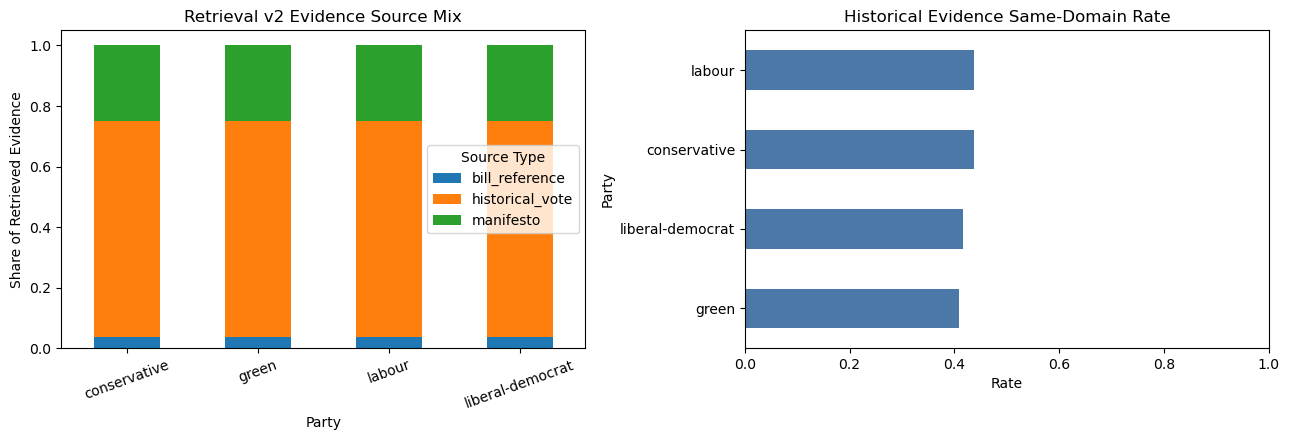

In [14]:
# 绘制来源结构和同领域历史证据比例。
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

source_mix = pd.crosstab(
    retrieval_v2['query_party'],
    retrieval_v2['source_type'],
    normalize='index',
)
source_mix.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Retrieval v2 Evidence Source Mix')
axes[0].set_xlabel('Party')
axes[0].set_ylabel('Share of Retrieved Evidence')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Source Type')

historical_metrics_v2['same_domain_rate'].sort_values().plot(
    kind='barh', ax=axes[1], color='#4C78A8'
)
axes[1].set_title('Historical Evidence Same-Domain Rate')
axes[1].set_xlabel('Rate')
axes[1].set_ylabel('Party')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 15. Build the v2 manual-review queue

继续选择 Green 最低分的6个查询和其他政党各2个最低分查询。与06b不同，这次队列同时包含更长的 query motion excerpt，避免审核时只看到标题。

你不需要自己阅读。运行后把 Summary 发给我，我会直接读取队列并复核。

In [15]:
# 生成低分压力样本的人工相关性审核队列。
review_query_ids = []
for party in PARTIES:
    query_count = 6 if party == 'green' else 2
    selected_ids = (
        query_metrics_v2[
            query_metrics_v2['query_party'].eq(party)
        ]
        .nsmallest(query_count, 'mean_adjusted_score')
        ['query_id']
        .tolist()
    )
    review_query_ids.extend(selected_ids)

manual_review_v2 = retrieval_v2[
    retrieval_v2['query_id'].isin(review_query_ids)
].copy()
manual_review_v2['query_motion_excerpt'] = (
    manual_review_v2['query_motion_text']
    .fillna('')
    .astype(str)
    .str.slice(0, 1000)
)
manual_review_v2['evidence_text_excerpt'] = (
    manual_review_v2['evidence_text']
    .fillna('')
    .astype(str)
    .str.slice(0, 1200)
)
manual_review_v2['manual_relevance'] = ''
manual_review_v2['manual_evidence_role'] = ''
manual_review_v2['manual_notes'] = ''

manual_review_columns = [
    'query_id', 'query_division_key', 'query_party', 'query_date',
    'query_title', 'query_policy_domain', 'query_motion_family',
    'query_policy_object', 'query_legislation', 'query_motion_excerpt',
    'rank', 'source_type', 'evidence_channel', 'base_score',
    'adjusted_score', 'domain_boost', 'title_overlap',
    'bill_direct_match', 'evidence_title', 'source_date', 'source_url',
    'stance_label', 'evidence_policy_domain', 'evidence_motion_family',
    'evidence_text_excerpt', 'manual_relevance',
    'manual_evidence_role', 'manual_notes',
]
manual_review_v2 = manual_review_v2[manual_review_columns]

print('Manual-review queries:', len(review_query_ids))
print('Manual-review evidence rows:', len(manual_review_v2))
display(manual_review_v2.head(16))

Manual-review queries: 12
Manual-review evidence rows: 96


,query_id,query_division_key,query_party,query_date,query_title,query_policy_domain,query_motion_family,query_policy_object,query_legislation,query_motion_excerpt,rank,source_type,evidence_channel,base_score,adjusted_score,domain_boost,title_overlap,bill_direct_match,evidence_title,source_date,source_url,stance_label,evidence_policy_domain,evidence_motion_family,evidence_text_excerpt,manual_relevance,manual_evidence_role,manual_notes
8,pw-2024-07-23-2-commons__green__adaptive_v2,pw-2024-07-23-2-commons,green,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,other_motion,NaN,NaN,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully fun...",1,manifesto,policy,0.055165,0.055165,0.000,0.000000,False,Green Party 2024 General Election Manifesto,2024-06-12,https://greenparty.org.uk/app/uploads/2024/06/Green-Party-2024-General-Election-Manifesto-Long-version-with-cover.pdf,NaN,NaN,NaN,"um, so that they recognise and\nunderstand how to use basic fresh produce.\nGrocery Standards Adjudicator and\nthe Food Standards Agency.\n• Reducing the vulnerability of the small-scale\n• A food...",,,
9,pw-2024-07-23-2-commons__green__adaptive_v2,pw-2024-07-23-2-commons,green,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,other_motion,NaN,NaN,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully fun...",2,manifesto,policy,0.052236,0.052236,0.000,0.000000,False,Green Party 2024 General Election Manifesto,2024-06-12,https://greenparty.org.uk/app/uploads/2024/06/Green-Party-2024-General-Election-Manifesto-Long-version-with-cover.pdf,NaN,NaN,NaN,"our food and farming\nsystem so it produces healthy, nutritious food at\nfair prices for consumers and with fair wages for\ngrowers. We will also aim to increase the amount\nof food that is grown ...",,,
10,pw-2024-07-23-2-commons__green__adaptive_v2,pw-2024-07-23-2-commons,green,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,other_motion,NaN,NaN,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully fun...",3,historical_vote,historical,0.142715,0.150215,0.000,0.125000,False,Amendment: Achieving Economic Growth,2022-05-18,None,support,economy_finance_business,other_motion,"Historical parliamentary vote.\nParty: green.\nObserved stance: support.\nMotion title: Amendment: Achieving Economic Growth.\nMotion text: I beg to move amendment (w), at the end of the Question ...",,,
11,pw-2024-07-23-2-commons__green__adaptive_v2,pw-2024-07-23-2-commons,green,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,other_motion,NaN,NaN,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully fun...",4,historical_vote,historical,0.119444,0.132778,0.000,0.222222,False,"Amendment: Economy, Welfare and Public Services",2024-07-22,None,oppose,economy_finance_business,other_motion,"Historical parliamentary vote.\nParty: green.\nObserved stance: oppose.\nMotion title: Amendment: Economy, Welfare and Public Services.\nMotion text: I beg to move an amendment, at the end of the ...",,,
12,pw-2024-07-23-2-commons__green__adaptive_v2,pw-2024-07-23-2-commons,green,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,other_motion,NaN,NaN,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully fun...",5,historical_vote,historical,0.111757,0.12

## 16. Save audit artifacts and print the review summary

In [16]:
# 保存完整证据、指标、配对比较和人工审核队列。
retrieval_v2.to_csv(
    AUDIT_V2_DIR / 'retrieval_v2_evidence.csv',
    index=False,
)
query_metrics_v2.to_csv(
    AUDIT_V2_DIR / 'retrieval_v2_query_metrics.csv',
    index=False,
)
source_metrics_v2.to_csv(
    AUDIT_V2_DIR / 'retrieval_v2_source_metrics.csv',
    index=False,
)
historical_metrics_v2.to_csv(
    AUDIT_V2_DIR / 'retrieval_v2_historical_metrics.csv'
)
green_paired_comparison.to_csv(
    AUDIT_V2_DIR / 'green_paired_comparison_v2.csv',
    index=False,
)
proxy_comparison.to_csv(
    AUDIT_V2_DIR / 'v1_v2_proxy_comparison.csv'
)
manual_review_v2.to_csv(
    AUDIT_V2_DIR / 'manual_relevance_review_queue_v2.csv',
    index=False,
)

source_counts = (
    retrieval_v2['source_type']
    .value_counts()
    .to_string()
)
result_distribution = (
    query_metrics_v2['results']
    .value_counts()
    .sort_index()
    .to_string()
)

summary_lines = [
    '=== RETRIEVAL V2 SUMMARY FOR REVIEW ===',
    f'Notebook version: {NOTEBOOK_VERSION}',
    'API calls: 0',
    'LLM calls: 0',
    'Manifesto extraction: default reading order, page-aware chunking',
    'Historical retrieval text excludes party, stance, motion type, motion family and domain labels',
    f'Audit sampling: deterministic stratified sample, random_state={RANDOM_STATE}',
    f'Audit divisions: {len(audit_divisions)}',
    f'Audit party queries: {len(query_metrics_v2)}',
    f'Audit policy domains: {audit_divisions["policy_domain_primary"].nunique()}',
    f'Audit motion families: {audit_divisions["motion_family"].nunique()}',
    f'Knowledge-base chunks: {len(chunks_v2)}',
    f'Sparse index shape: {sparse_matrix_v2.shape}',
    f'Structural gates: {structural_gates}',
    f'Queries with fewer than 8 results: {int(query_metrics_v2["results"].lt(TOP_K).sum())}',
    f'Bill query coverage rate: {query_metrics_v2["bill_results"].gt(0).mean():.3f}',
    f'Historical same-domain rate: {historical_v2["same_domain"].mean():.3f}',
    f'Historical same-family rate: {historical_v2["same_family"].mean():.3f}',
    f'Manual-review queries: {len(review_query_ids)}',
    f'Manual-review evidence rows: {len(manual_review_v2)}',
    'Evidence source counts:',
    source_counts,
    'Results per query distribution:',
    result_distribution,
    'V1 vs V2 relevance proxies:',
    proxy_comparison.round(4).to_string(),
    'Green paired comparison:',
    green_paired_comparison.round(4).to_string(index=False),
    f'RAG v2 output directory: {RAG_V2_DIR}',
    f'Audit output directory: {AUDIT_V2_DIR}',
    'Next step: review the v2 manual queue before any paid LLM evaluation.',
    '=== END RETRIEVAL V2 SUMMARY ===',
]
summary_text = '\n'.join(summary_lines)
(AUDIT_V2_DIR / 'rag_retrieval_v2_summary.txt').write_text(
    summary_text,
    encoding='utf-8',
)
print(summary_text)

=== RETRIEVAL V2 SUMMARY FOR REVIEW ===
Notebook version: 06c-rag-retrieval-v2
API calls: 0
LLM calls: 0
Manifesto extraction: default reading order, page-aware chunking
Historical retrieval text excludes party, stance, motion type, motion family and domain labels
Audit sampling: deterministic stratified sample, random_state=42
Audit divisions: 24
Audit party queries: 96
Audit policy domains: 12
Audit motion families: 4
Knowledge-base chunks: 4504
Sparse index shape: (4504, 74188)
Structural gates: {'maximum_8_results_gate': True, 'minimum_4_results_gate': True, 'temporal_leakage_gate': True, 'same_division_gate': True, 'duplicate_chunk_gate': True, 'document_diversity_gate': True}
Queries with fewer than 8 results: 0
Bill query coverage rate: 0.292
Historical same-domain rate: 0.425
Historical same-family rate: 0.699
Manual-review queries: 12
Manual-review evidence rows: 96
Evidence source counts:
source_type
historical_vote    548
manifesto          192
bill_reference      28
Results